<div style="text-align: center;">
    <h1>Выпускной проект<br>        
        Банки - Анализ оттока клиентов</h1>
</div>

### Цель исследования:
Проанализировать поведение клиентов банка и выделить ключевые сегменты, склонные к оттоку, а также предложить рекомендации по снижению этого показателя.

### Задачи:
1. Проанализировать клиентов регионального банка и выделить сегменты клиентов, склонные уходить из банка.  
2. Провести исследовательский анализ данных, определить все значимые признаки оттока (интервалы значений характеристик, связанные с повышенным оттоком, сравнить портреты типичных клиентов, которые склонны и не склонны уходить из банка).  
3. Сформулировать и проверить статистические гипотезы:  
   - Проверить гипотезу различия дохода между клиентами, которые ушли, и теми, которые остались.  
   - Проверить дополнительные гипотезы относительно представленных данных.  
4. Объединяя признаки оттока, сформировать сегменты клиентов, выделить из них ключевые и дать рекомендации.  

---

### Описание данных:
**Файл:** `bank_scrooge.csv`  
**Описание колонок:**  
- `USERID` — идентификатор пользователя.  
- `score` — баллы кредитного скоринга.  
- `city` — город проживания.  
- `gender` — пол клиента.  
- `age` — возраст клиента.  
- `equity` — количество баллов собственности.  
- `balance` — баланс на счёте.  
- `products` — количество продуктов, которыми пользуется клиент.  
- `credit_card` — наличие кредитной карты.  
- `last_activity` — активность клиента.  
- `EST_SALARY` — оценочный доход клиента.  
- `churn` — признак оттока (1 — клиент ушёл, 0 — остался).  


<div style="text-align: center;">
    <h1>1. Загрузка и первичная обработка данных:</h1>
</div>

In [1]:
# Основные библиотеки для работы с данными
import pandas as pd  # Работа с таблицами
import numpy as np  # Математические операции

# Для визуализации
import matplotlib.pyplot as plt  # Построение графиков
import seaborn as sns  # Статистическая визуализация

# Для статистических тестов
from scipy import stats  # Статистические методы
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from scipy.stats import shapiro
from scipy.stats import f_oneway

# Для кластеризации и машинного обучения
from sklearn.preprocessing import StandardScaler  # Стандартизация данных
from sklearn.cluster import KMeans, DBSCAN # Методы кластеризации 
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster 
#Эта часть библиотеки SciPy используется для выполнения иерархической кластеризации
from sklearn.metrics import silhouette_score 
#Эта функция из библиотеки scikit-learn вычисляет коэффициент силуэта для оценки качества кластеризации

# Для работы с предупреждениями
import warnings
warnings.filterwarnings("ignore")  # Отключение предупреждений


_Импортируем основные библиотеки для работы с данными_

In [2]:
# Загрузка данных
file_path = "https://code.s3.yandex.net/datasets/bank_scrooge.csv"

try:
    data = pd.read_csv(file_path)
    print("Данные успешно загружены!")
except Exception as e:
    print(f"Произошла ошибка при загрузке данных: {e}")

Данные успешно загружены!


In [3]:
# 1. Ознакомиться со структурой данных, колонками и типами данных
print("Общая информация о данных:")
data.info()

print("\nПервые 5 строк таблицы:")
print(data.head())

Общая информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB

Первые 5 строк таблицы:
   USERID  score       city gender   age  equity     balance  products  \
0  183012  850.0    Рыбинск      Ж  25.0       1    59214.82         2   
1  146556  8

**Общая структура данных:**

* Датасет содержит 12 колонок и 10 000 строк.
* Имеются числовые, категориальные и строковые признаки.
* Объем данных достаточен для анализа, но требуется очистка и предобработка.


In [4]:
# 2. Проверить данные на пропуски
print("\nПроверка пропусков в данных:")
print(data.isnull().sum())  


Проверка пропусков в данных:
USERID              0
score               0
city                0
gender              0
age                26
equity              0
balance          2295
products            0
credit_card         0
last_activity       0
EST_SALARY          0
churn               0
dtype: int64


**Пропуски:**

Пропуски обнаружены в двух колонках:

 * *age*: 26 пропущенных значений.
 
 * *balance*: 2295 пропущенных значений.
 
 Остальные колонки полные и не содержат пропусков.
 

In [5]:
# 3. Приведение данных к подходящим типам
# например, 'USERID' как строка, а категориальные колонки в категорийный тип
data['USERID'] = data['USERID'].astype(str)  # Приводим идентификатор к строке
categorical_columns = ['city', 'gender', 'credit_card', 'last_activity', 'churn']
for col in categorical_columns:
    data[col] = data[col].astype('category')  

_Приводим к категорийным типам_

In [6]:
#4 Проверка уникальности идентификаторов (USERID)
print("\nПроверка уникальности USERID:")
print(f"Количество уникальных значений USERID: {data['USERID'].nunique()}")
print(f"Общее количество строк в датасете: {len(data)}")

if data['USERID'].nunique() == len(data):
    print("Все идентификаторы уникальны.")
else:
    print("Есть дублирующиеся идентификаторы.")
    
    # Находим пары строк с одинаковыми USERID
    duplicates = data[data['USERID'].duplicated(keep=False)]
    print("\nПары строк с одинаковыми идентификаторами USERID:")
    for userid, group in duplicates.groupby('USERID'):
        print(f"\nUSERID: {userid}")
        print(group)



Проверка уникальности USERID:
Количество уникальных значений USERID: 9927
Общее количество строк в датасете: 10000
Есть дублирующиеся идентификаторы.

Пары строк с одинаковыми идентификаторами USERID:

USERID: 116540
      USERID  score       city gender   age  equity    balance  products  \
1893  116540  883.0    Рыбинск      Ж  55.0       1  362756.49         3   
7694  116540  887.0  Ярославль      Ж  38.0       0        NaN         1   

     credit_card last_activity  EST_SALARY churn  
1893           0             1   175920.48     1  
7694           0             1   119247.61     0  

USERID: 117943
      USERID  score       city gender   age  equity     balance  products  \
4866  117943  855.0    Рыбинск      Ж  32.0       6  1036832.93         4   
7542  117943  880.0  Ярославль      Ж  40.0       0         NaN         1   

     credit_card last_activity  EST_SALARY churn  
4866           1             1   107792.71     1  
7542           1             0   137718.93     0  

**Уникальность USERID:**

* Количество уникальных идентификаторов (USERID) составляет 9927 при общем количестве строк 10 000.

* В датасете имеются 73 дублирующихся идентификатора. Причиной может быть повторное присваивание того же идентификатора новому клиенту после ухода старого. Есть клиенты из разных городов, разного возраста. Также это может быть ошибкой сбора данных. 


In [7]:
# 5. Проверка на аномалии
# Проверим числовые признаки на выбросы и отрицательные значения
numeric_columns = ['score', 'age', 'equity', 'balance', 'products', 'EST_SALARY']
print("\nПроверка числовых колонок на отрицательные значения:")
for col in numeric_columns:
    if (data[col] < 0).any():
        print(f"Колонка '{col}' содержит отрицательные значения.")
    else:
        print(f"Колонка '{col}' не содержит отрицательных значений.")

# Вывод основных статистик для поиска выбросов
print("\nОписательная статистика по числовым колонкам:")
print(data[numeric_columns].describe())

# Для категориальных колонок проверим уникальные значения
print("\nПроверка уникальных значений для категориальных колонок:")
for col in categorical_columns:
    print(f"\nКолонка '{col}':")
    print(data[col].value_counts())


Проверка числовых колонок на отрицательные значения:
Колонка 'score' не содержит отрицательных значений.
Колонка 'age' не содержит отрицательных значений.
Колонка 'equity' не содержит отрицательных значений.
Колонка 'balance' не содержит отрицательных значений.
Колонка 'products' не содержит отрицательных значений.
Колонка 'EST_SALARY' не содержит отрицательных значений.

Описательная статистика по числовым колонкам:
              score          age        equity       balance      products  \
count  10000.000000  9974.000000  10000.000000  7.705000e+03  10000.000000   
mean     848.699400    42.734409      2.627600  8.277943e+05      1.870100   
std       65.448519    12.179971      1.980836  1.980614e+06      0.792647   
min      642.000000    18.000000      0.000000  0.000000e+00      0.000000   
25%      802.000000    33.000000      0.000000  2.955542e+05      1.000000   
50%      853.000000    40.000000      3.000000  5.242722e+05      2.000000   
75%      900.000000    51.000000

**Числовые признаки:**

Все числовые признаки не содержат отрицательных значений.

Обнаружены аномально высокие значения в некоторых колонках:

* *balance*: максимальное значение составляет 119 миллионов, что значительно превышает 75-й перцентиль (0,98 млн). Это может быть выброс.

* *EST_SALARY*: максимальный доход составляет 1,4 млн, что также может быть выбросом, учитывая среднее значение в 147 тыс.

* *age*: значения в пределах нормы (от 18 до 86 лет).

**Категориальные признаки:**

* *city*: Три города представлены в данных: Ярославль (58,88%), Рыбинск (26,95%) и Ростов (14,17%).

* *gender*: Распределение между мужчинами и женщинами почти равное (50,05% мужчин, 49,95% женщин).

* *credit_card*: Большинство клиентов (68%) имеют кредитную карту.

* *last_activity*: 52,35% клиентов активны.

* *churn*: 18,2% клиентов покидают банк, что является важным целевым признаком.



**Предварительные выводы и задачи для обработки:**

* Необходимо обработать пропуски в колонках age и balance.

* Проанализировать дублирующиеся USERID и решить, как с ними поступить (удаление или объединение записей).

* Выбросы в колонках balance и EST_SALARY требуют дополнительного анализа и, возможно, устранения.

* Приведение данных к стандартному формату завершено для всех категориальных и числовых признаков.

**Следующие шаги:**

* Заполнить или обработать пропуски в колонках age и balance.

* Проверить и устранить дублирующиеся USERID.

* Выполнить анализ выбросов в колонках balance и EST_SALARY.

* Начать анализ корреляций и значимых признаков для оттока клиентов (churn).

<div style="text-align: center;">
    <h1>1. Предобработка данных:</h1>
</div>

**Обработка числовых данных:**
   - Преобразуются числовые колонки (`score`, `age`, `equity`, `balance`, `products`, `EST_SALARY`) в формат чисел с плавающей запятой, используя метод `pd.to_numeric` с параметром `errors='coerce'`. Это заменяет некорректные значения (например, текстовые строки) на `NaN`.

In [8]:
# 1. Убедимся, что числовые колонки действительно числовые
# Преобразуем данные в числовых колонках, заменяя некорректные значения на NaN
numeric_columns = ['score', 'age', 'equity', 'balance', 'products', 'EST_SALARY']
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Проверим, что все числовые колонки корректны
print(data[numeric_columns].dtypes)



score         float64
age           float64
equity          int64
balance       float64
products        int64
EST_SALARY    float64
dtype: object


Также рассмотрим отдельно колонку 'products'

In [9]:
# Проверка уникальных значений в колонке 'products'
unique_products = data['products'].unique()

# Вывод уникальных значений
print("Уникальные значения в колонке 'products':")
print(unique_products)

# Подсчет частоты каждого уникального значения
product_counts = data['products'].value_counts()

# Вывод частот значений
print("\nЧастота значений в колонке 'products':")
print(product_counts)

Уникальные значения в колонке 'products':
[2 3 1 4 5 0]

Частота значений в колонке 'products':
products
2    5126
1    3341
3    1039
4     474
5      19
0       1
Name: count, dtype: int64


Интересно что в одной строке количество продуктов равно 0.

In [10]:
# Фильтрация строк, где 'products' равно 0
rows_with_zero_products = data[data['products'] == 0]

# Просмотр первых нескольких строк
print(rows_with_zero_products)

      USERID  score     city gender   age  equity  balance  products  \
8957  147837  962.0  Рыбинск      Ж  79.0       3      NaN         0   

     credit_card last_activity  EST_SALARY churn  
8957           0             0    25063.96     1  


Женщина, 79 лет, из Рыбинска, без кредитки и активности в последнее время и без данных о балансе. С большой вероятностью умерла, и родные активно закрывают ее счета. Удаляем эту строку.

In [11]:
# Удаление строк, где 'products' равно 0
data = data[data['products'] != 0]

**Заполнение пропусков:**
   - Пропуски в колонке `age` заполняются медианным значением, чтобы сохранить распределение возраста клиентов.
    
    **Проверка пропусков:**
   - После заполнения пропусков выводится количество оставшихся `NaN` в каждой колонке, чтобы удостовериться, что пропуски обработаны.

In [12]:
# 2. Заполнение пропусков в колонке 'age' медианным значением
median_age = data['age'].median()  # Вычисляем медиану для столбца 'age'
data['age'].fillna(median_age, inplace=True)  # Заполняем пропуски медианным значением

# Проверка пропусков после заполнения
missing_values = data.isnull().sum()  # Считаем количество пропусков в каждой колонке
print("Количество пропусков после обработки:")
print(missing_values)


Количество пропусков после обработки:
USERID              0
score               0
city                0
gender              0
age                 0
equity              0
balance          2294
products            0
credit_card         0
last_activity       0
EST_SALARY          0
churn               0
dtype: int64


### Анализ пропусков в колонке balance и их зависимости от других данных

- Добавляем столбец, указывающий наличие данных о балансе (True/False).

- Исследуем зависимость наличия данных о балансе от других признаков.

has_balance
True     7705
False    2294
Name: count, dtype: int64

Пропорция строк с пропусками в колонке 'balance':
has_balance
True     0.770577
False    0.229423
Name: proportion, dtype: float64

Анализ зависимости от столбца: city
p-value: 0.0000
Зависимость между 'has_balance' и 'city' статистически значима.

Анализ зависимости от столбца: gender
p-value: 0.0000
Зависимость между 'has_balance' и 'gender' статистически значима.

Анализ зависимости от столбца: credit_card
p-value: 0.0000
Зависимость между 'has_balance' и 'credit_card' статистически значима.

Анализ зависимости от столбца: products
p-value: 0.0000
Зависимость между 'has_balance' и 'products' статистически значима.

Анализ зависимости от столбца: churn
p-value: 0.0000
Зависимость между 'has_balance' и 'churn' статистически значима.


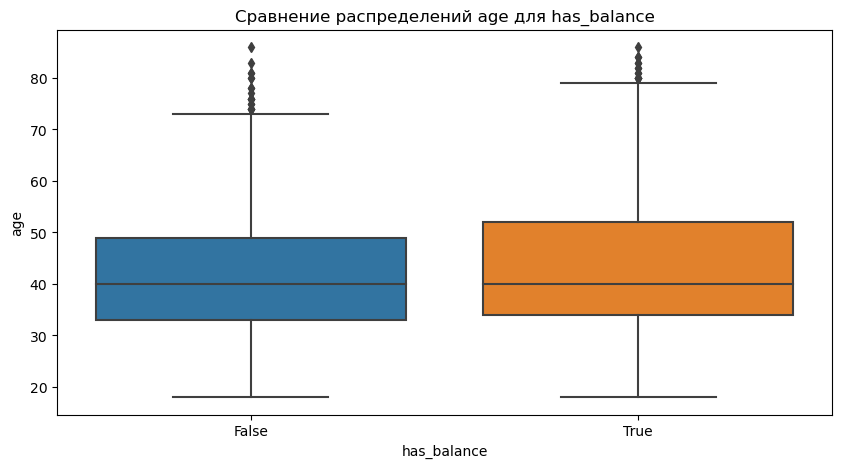

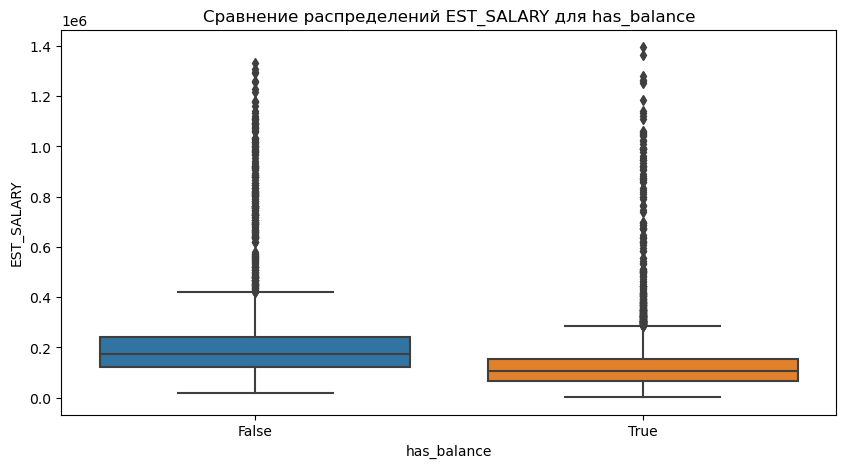

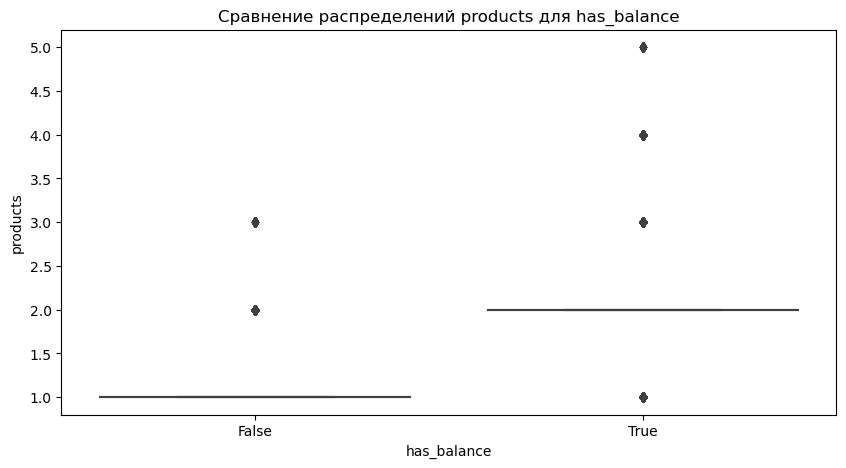

In [13]:
# Создаем новый столбец для указания наличия данных о балансе
data['has_balance'] = data['balance'].notnull()

# Проверяем количество пропусков и наличие данных
print(data['has_balance'].value_counts())
print("\nПропорция строк с пропусками в колонке 'balance':")
print(data['has_balance'].value_counts(normalize=True))

# Проверим, зависит ли наличие данных о балансе от категориальных переменных
categorical_columns = ['city', 'gender', 'credit_card', 'products', 'churn']

for col in categorical_columns:
    print(f"\nАнализ зависимости от столбца: {col}")
    contingency_table = pd.crosstab(data['has_balance'], data[col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"p-value: {p:.4f}")
    if p < 0.05:
        print(f"Зависимость между 'has_balance' и '{col}' статистически значима.")
    else:
        print(f"Зависимость между 'has_balance' и '{col}' незначима.")

# Анализ числовых данных: сравнение распределений для наличия/отсутствия баланса
numerical_columns = ['age', 'EST_SALARY', 'products']

for col in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=data, x='has_balance', y=col)
    plt.title(f"Сравнение распределений {col} для has_balance")
    plt.show()

# Обоснование выбранных методов анализа зависимости

### 1. Обоснование анализа зависимости от категориальных переменных (использование хи-квадрат теста)

### Почему выбран хи-квадрат тест?
Хи-квадрат тест (\(\chi^2\)) используется для проверки статистической зависимости между двумя категориальными переменными. В данном случае:
- `has_balance` — бинарная переменная (наличие или отсутствие данных о балансе).
- Переменные из `categorical_columns` — категориальные.

"Мы используем хи-квадрат тест, так как обе переменные категориальные. Метод позволяет определить, существует ли статистически значимая зависимость между `has_balance` и выбранными переменными (например, `city`, `gender`, и т.д.). Если p-value < 0.05, это означает, что зависимость значима, и наличие пропусков в балансе может быть связано с этими категориями."

---

### 2. Обоснование анализа числовых переменных (использование графиков и boxplot)

### Почему выбран boxplot?
Boxplot наглядно отображает распределение числовых данных (`age`, `EST_SALARY`, `products`) в группах (наличие/отсутствие баланса). Это помогает выявить различия в медианах, выбросах и разбросе значений между группами.

"Мы исследуем, как числовые переменные (`age`, `EST_SALARY`, и т.д.) различаются между группами `has_balance` (наличие или отсутствие данных о балансе). Для этого строятся boxplot, которые позволяют визуально сравнить распределения и выявить возможные зависимости."




- В данном случае почти 23% данных имеют пропуски, и удаление этих строк может привести к значительной потере информации и снижению репрезентативности выборки. Низкие p-value (0.0000) указывают на статистически значимые связи между отсутствием данных в balance и признаками city, gender, credit_card, products, и churn. 

- Заполнять их медианой, или же значениями, предсказанными с помощью модели, будет не корректно. Оставляем пропуски в балансе как есть, и учитываем их в дальнейшем анализе.

**Удаление выбросов:**

1. Аномальные значения могут быть реальными данными.

Некоторые клиенты действительно могут иметь крайне высокие или низкие значения баланса. Например:

- Вкладчики с крупными суммами (миллионы).
- Клиенты с минимальными средствами (нулевой баланс).

Если эти значения отражают реальные данные, их удаление исказит анализ. Это особенно важно, если такие клиенты составляют специфическую и интересующую группу, например, высокодоходные клиенты или клиенты с риском оттока.

2. Выбросы могут быть информативными

Аномальные значения могут помочь выявить:

- Уникальные паттерны поведения (например, нулевой баланс может указывать на неудовлетворённость).
- Корреляции с другими показателями, например, связь между балансом и оттоком.

3. Уменьшение объёма данных

Удаление строк с выбросами может значительно сократить объём данных, что уменьшит статистическую значимость и обобщающую способность моделей. Это особенно критично, если размер выборки ограничен.

**Проверка категориальных данных:**
   - Выводятся уникальные значения для категориальных колонок (`city`, `gender`, `credit_card`, `last_activity`, `churn`) для проверки корректности данных.

In [14]:
# 4. Проверка категориальных колонок
print("\nПроверка уникальных значений для категориальных колонок:")
for col in ['city', 'gender', 'credit_card', 'last_activity', 'churn']:
    print(f"{col}: {data[col].unique()}")




Проверка уникальных значений для категориальных колонок:
city: ['Рыбинск', 'Ярославль', 'Ростов']
Categories (3, object): ['Ростов', 'Рыбинск', 'Ярославль']
gender: ['Ж', 'М']
Categories (2, object): ['Ж', 'М']
credit_card: [0, 1]
Categories (2, int64): [0, 1]
last_activity: [1, 0]
Categories (2, int64): [0, 1]
churn: [1, 0]
Categories (2, int64): [0, 1]


Категориальные данные делятся на упорядоченные (уровень образования, удовлетворённости пользователя) и неупорядоченные (город, брачный статус и т.п.). Центральные тенденции второго можно смотреть при помощи моды. Будет некорректно задавать неупорядоченным категориям какой-то числовой порядок и смотреть средние арифметические. К средним каких-то ординальных показателей, или численных показателей, содержащих большое число значений, например возраста, надо относиться так, что это центр распределения, которое может иметь какую-то сложную природу. Бинарные показатели, если к ним применить среднее, показывают нам долю тех клиентов, у которых этот бинарный показатель равен единице.

Для того, чтобы применять среднее и смотреть корреляции какого-то числового показателя с категориальным неупорядоченным, можно применить one-hot кодирование, проще всего это сделать при помощи pandas.get_dummies. Чтобы при этом не потерять оригинальный столбец, стоит сделать его копию и использовать параметр columns (чтобы перекодированию подвергся или подверглись только те столбцы, которые нам нужно перекодировать).

In [15]:
# 5. Кодирование категориальных признаков
# Создаем копии исходных категориальных колонок
categorical_columns = ['city', 'gender']
data_encoded = data.copy()

# Применяем One-Hot Encoding
encoded_columns = pd.get_dummies(data[categorical_columns], columns=categorical_columns)
data_encoded = pd.concat([data_encoded, encoded_columns], axis=1)

# Удаляем оригинальные категориальные колонки, если они не нужны в дальнейшем анализе
data_encoded.drop(columns=categorical_columns, inplace=True)

print("\nКатегориальные признаки после кодирования:")
print(data_encoded.head())



Категориальные признаки после кодирования:
   USERID  score   age  equity     balance  products credit_card  \
0  183012  850.0  25.0       1    59214.82         2           0   
1  146556  861.0  37.0       5   850594.33         3           1   
2  120722  892.0  30.0       0         NaN         1           1   
3  225363  866.0  51.0       5  1524746.26         2           0   
4  157978  730.0  34.0       5      174.00         1           1   

  last_activity  EST_SALARY churn  has_balance  city_Ростов  city_Рыбинск  \
0             1    75719.14     1         True        False          True   
1             0    86621.77     0         True        False          True   
2             1   107683.34     0        False        False          True   
3             1   174423.53     1         True        False         False   
4             0    67353.16     1         True        False         False   

   city_Ярославль  gender_Ж  gender_М  
0           False      True     False  
1   

**Обработка дубликатов:**
   - В датасете имеются 73 дублирующихся идентификатора. Причиной может быть повторное присваивание того же идентификатора новому клиенту после ухода старого. Есть клиенты из разных городов, разного возраста. Также это может быть ошибкой сбора данных.Так как мы имеем всего 10000 строк в исходнике, не удаляем. Эти данные будут полезны для дальнейшего анализа.

### Вывод к этапу предобработки данных:

На этапе предобработки данных была выполнена комплексная очистка и подготовка информации для дальнейшего анализа.

1. **Обработка числовых данных**:  
   - Все числовые колонки приведены к единому формату (`float`), некорректные значения заменены на пропуски (`NaN`).  
   - Пропуски в колонке `age` заполнены медианными значениями, что позволило сохранить распределение данных.

2. **Удаление выбросов**:  
   - Удаление строк с выбросами может значительно сократить объём данных, что уменьшит статистическую значимость и обобщающую способность моделей. Это особенно критично, если размер выборки ограничен

3. **Работа с категориальными данными**:  
   - Проверены уникальные значения категориальных колонок (`city`, `gender`, `credit_card`, и др.) на наличие аномалий и ошибок ввода.  
   - Добавлены столбцы `city_Ростов`, `city_Рыбинск`, `city_Ярославль`, где False - не этот город, True - этот город
4. **Обработка дубликатов**:  
   - Выявлены дублирующиеся записи по идентификатору клиента (`USERID`).  
   - Принято решение не удалять.

---

В результате этапа предобработки:  
- Данные проверены на пропуски, выбросы и дубликаты.  
- Признаки приведены к единому формату.  
- Получены данные, готовые к проведению исследовательского анализа и построению моделей.  

Предобработка обеспечивает корректность и достоверность последующих выводов и анализа.


<div style="text-align: center;">
    <h1>2. Исследовательский анализ данных (EDA):</h1>
</div>

 Исследовательский анализ данных (EDA):
- **Общая статистика:**  
  - Анализ числовых колонок (распределения, средние, медианы и пр.).  
  - Анализ категориальных переменных (распределение и частотность).  
- **Анализ оттока:**  
  - Доля клиентов, покинувших банк.  
  - Сравнение характеристик клиентов, ушедших и оставшихся.  
- **Анализ признаков:**  
  - Построение распределений (возраст, доход, баланс и т.д.).  
  - Выявление ключевых характеристик, связанных с повышенным оттоком.  
  - Сравнение портретов клиентов, склонных и не склонных к оттоку.  
- **Визуализация:**  
  - Построение графиков (гистограммы, boxplot, корреляционные тепловые карты). 

Описательная статистика числовых колонок:
             score          age       equity       balance     products  \
count  9999.000000  9999.000000  9999.000000  7.705000e+03  9999.000000   
mean    848.688069    42.723672     2.627563  8.277943e+05     1.870287   
std      65.441981    12.160120     1.980931  1.980614e+06     0.792466   
min     642.000000    18.000000     0.000000  0.000000e+00     1.000000   
25%     802.000000    33.000000     0.000000  2.955542e+05     1.000000   
50%     853.000000    40.000000     3.000000  5.242722e+05     2.000000   
75%     900.000000    51.000000     4.000000  9.807058e+05     2.000000   
max    1000.000000    86.000000     9.000000  1.191136e+08     5.000000   

         EST_SALARY  
count  9.999000e+03  
mean   1.478792e+05  
std    1.393901e+05  
min    2.546300e+03  
25%    7.525212e+04  
50%    1.196615e+05  
75%    1.745011e+05  
max    1.395064e+06  


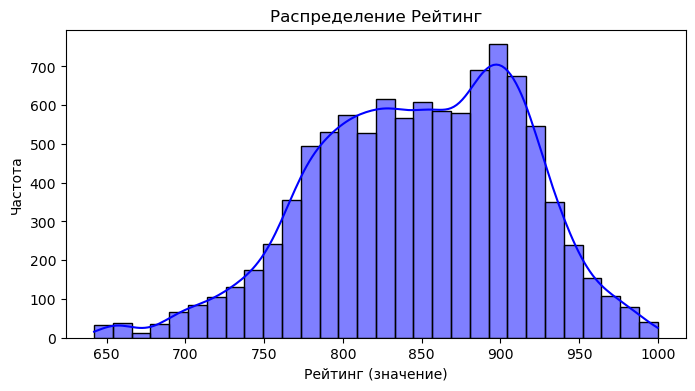

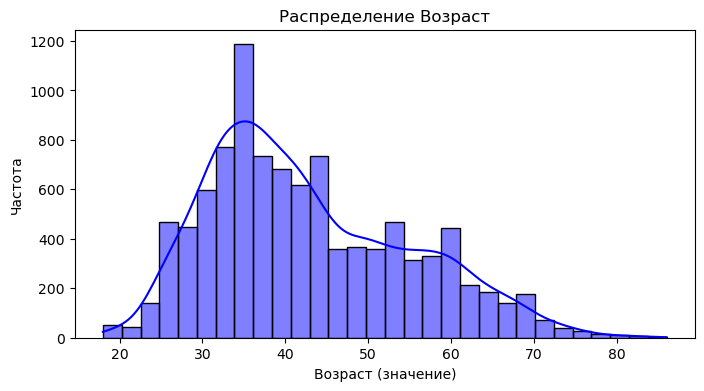

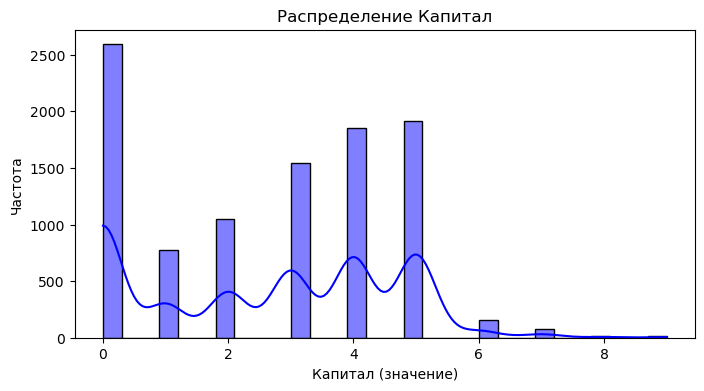

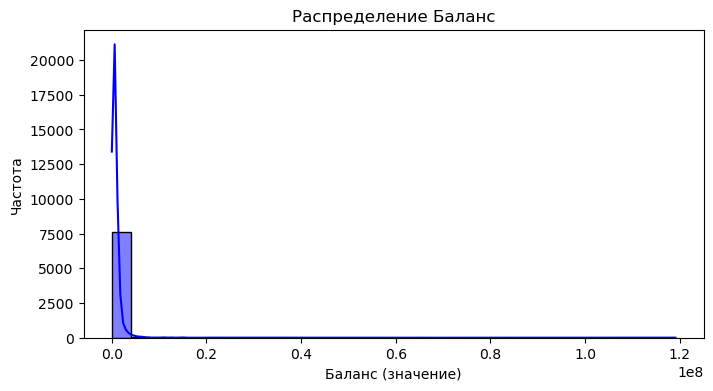

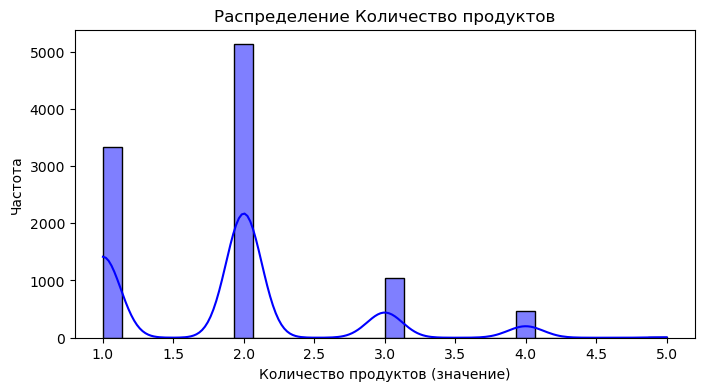

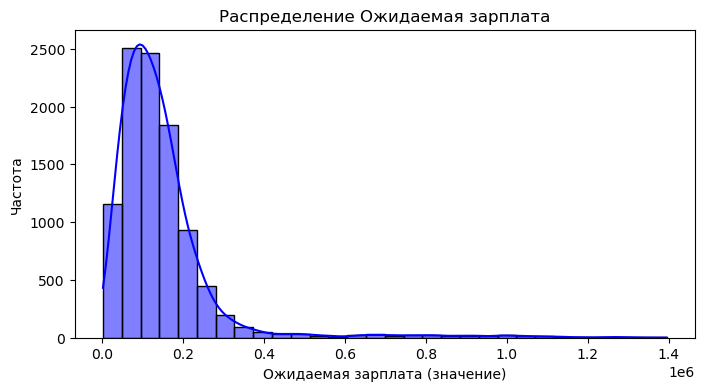

In [16]:
# 1. Общая статистика числовых колонок
numeric_columns = ['score', 'age', 'equity', 'balance', 'products', 'EST_SALARY']

# Описательная статистика числовых колонок
print("Описательная статистика числовых колонок:")
print(data[numeric_columns].describe())

# Словарь переводов для колонок
column_translations = {
    'score': 'Рейтинг',
    'age': 'Возраст',
    'equity': 'Капитал',
    'balance': 'Баланс',
    'products': 'Количество продуктов',
    'EST_SALARY': 'Ожидаемая зарплата'
}


# Построение гистограмм для числовых колонок с русскими подписями
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True, bins=30, color='blue')
    plt.title(f"Распределение {column_translations[col]}")  # Заголовок на русском
    plt.xlabel(f"{column_translations[col]} (значение)")    # Подпись оси X на русском
    plt.ylabel("Частота")                                  # Подпись оси Y на русском
    plt.show()

1. score (оценка клиента):

- Среднее значение: 848.69, что говорит о высокой средней оценке среди клиентов.
- Стандартное отклонение: 65.44, относительно небольшое, что указывает на умеренную вариативность.
- Минимальное и максимальное значения: варьируется от 642 до 1000, без выбросов.
- Медиана (50-й процентиль): 853, близка к среднему значению, что указывает на симметричное распределение.

2. age (возраст):

- Средний возраст: 42.72 года, типичный для взрослой аудитории банков.
- Стандартное отклонение: 12.16, что указывает на широкую возрастную группу клиентов.
- Минимальное и максимальное значения: от 18 до 86 лет, диапазон охватывает молодую и пожилую аудиторию.
- Квартильные границы:
- 25% клиентов моложе 33 лет.
- 50% клиентов моложе 40 лет.
- 75% клиентов моложе 51 года.

3. equity (количество активов):

- Среднее значение: 2.63, что может отражать типичное количество активов или продуктов, которыми пользуются клиенты.
- Стандартное отклонение: 1.98, что указывает на значительное различие между клиентами.
- Минимальное и максимальное значения: от 0 до 9.
- Медиана: 3, что говорит о том, что большая часть клиентов имеет до 3 активов.

4. balance (баланс на счёте):

- Среднее значение: 827,794.30, что может указывать на значительную сумму среднего остатка.
- Стандартное отклонение: 1,980,614, что указывает на высокую вариативность (есть как клиенты с нулевым балансом, так и клиенты с огромными суммами).
- Минимальное и максимальное значения: от 0 до 119,113,600.
- Медиана: 524,272.20 — 50% клиентов имеют баланс менее этой суммы.

5. products (количество продуктов):

- Среднее значение: 1.87, большинство клиентов используют 1 или 2 продукта банка.
- Стандартное отклонение: 0.79, небольшая вариативность.
- Минимальное и максимальное значения: от 1 до 5.
- Медиана: 2, что подтверждает преобладание клиентов с 2 продуктами.

6. EST_SALARY (оценочная зарплата):

- Среднее значение: 147,879.20, что указывает на довольно высокий уровень дохода клиентов.
- Стандартное отклонение: 139,390.10, указывает на значительное различие в доходах.
- Минимальное и максимальное значения: от 2,546.30 до 1,395,064.
- Медиана: 119,661.50 — половина клиентов имеет доход меньше этой суммы.

**Общие выводы:**

- Клиенты банка — в основном взрослые люди среднего возраста с относительно высоким уровнем дохода.
- Большинство клиентов имеют 1–2 продукта банка и остатки на счетах от нескольких тысяч до миллионов.
- Наблюдается высокая вариативность в данных, особенно в колонках balance и EST_SALARY, что может быть связано с разной целевой аудиторией (от массовых клиентов до премиальных).


Частотность значений в city:
city
Ярославль    5888
Рыбинск      2694
Ростов       1417
Name: count, dtype: int64


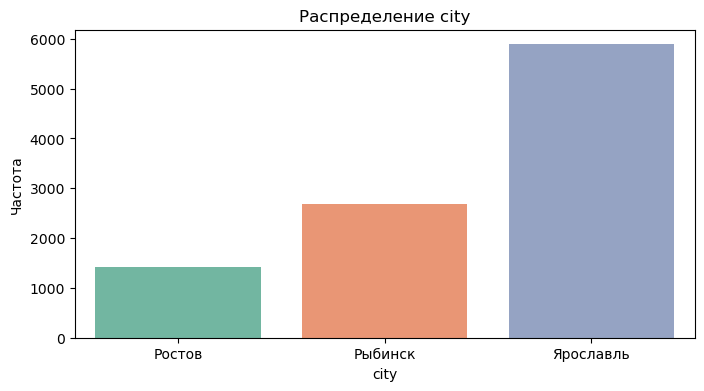


Частотность значений в gender:
gender
М    5005
Ж    4994
Name: count, dtype: int64


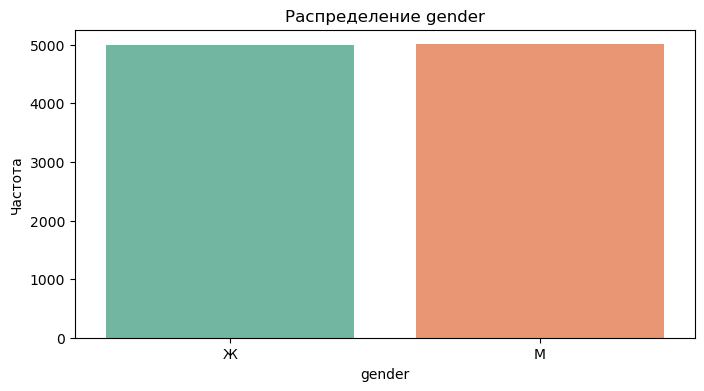


Частотность значений в credit_card:
credit_card
1    6804
0    3195
Name: count, dtype: int64


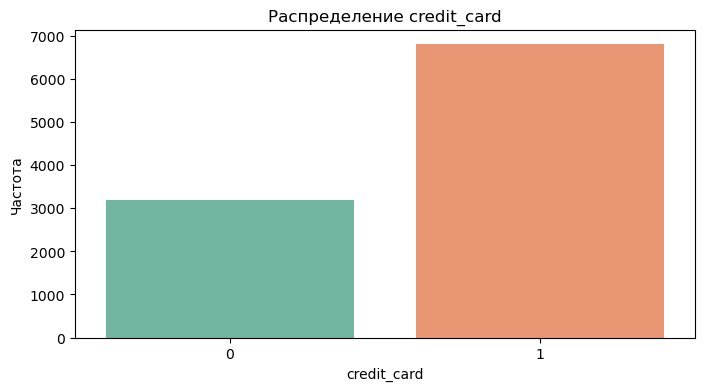


Частотность значений в last_activity:
last_activity
1    5235
0    4764
Name: count, dtype: int64


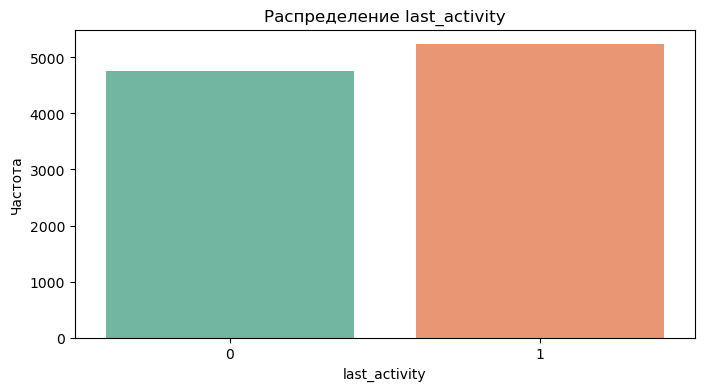


Частотность значений в churn:
churn
0    8180
1    1819
Name: count, dtype: int64


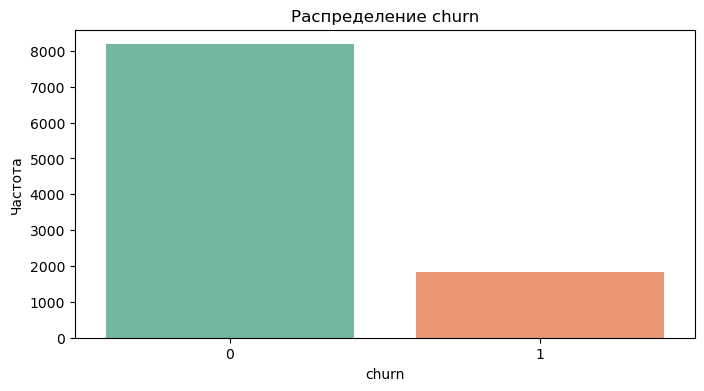

In [17]:
# 2. Анализ категориальных переменных
categorical_columns = ['city', 'gender', 'credit_card', 'last_activity', 'churn']

for col in categorical_columns:
    print(f"\nЧастотность значений в {col}:")
    print(data[col].value_counts())
    
    # Построение графиков распределения для категориальных данных
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, palette='Set2')
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show()



**Описание частотности значений в категориальных переменных:**

1. city (город проживания):

- Большинство клиентов проживают в Ярославле — 5888 человек (59% от общего числа).
- Значительное количество клиентов в Рыбинске — 2694 человека (27%).
- Меньше всего клиентов из Ростова — 1417 человек (14%).
- Вывод: Клиентская база банка сосредоточена преимущественно в Ярославле, что может повлиять на стратегию локальных предложений.

2. gender (пол):

- Мужчины составляют 5005 человек (50.1%).
- Женщины составляют 4994 человека (49.9%).
- Вывод: Пол клиентов распределён практически поровну, что говорит о сбалансированной демографической структуре.

3. credit_card (наличие кредитной карты):

- У 6804 клиентов (68%) есть кредитная карта.
- У 3195 клиентов (32%) кредитной карты нет.
- Вывод: Большинство клиентов пользуются кредитными картами, что говорит о популярности этого продукта.

4. last_activity (активность за последнее время):

- 5235 клиентов (52.4%) были активны в последнее время.
- 4764 клиента (47.6%) не проявляли активности.
- Вывод: Почти половина клиентской базы не проявляла активности, что может быть сигналом для проработки стратегий повторного вовлечения.

5. churn (отток клиентов):

- 8180 клиентов (81.8%) остались в банке.
- 1819 клиентов (18.2%) покинули банк.
- Вывод: Уровень оттока составляет 18.2%, что является значительной величиной, требующей анализа причин и разработки мер по удержанию клиентов.

**Общие выводы:**

- Основной клиентский сегмент — это жители Ярославля, примерно поровну мужчины и женщины.
- Большинство клиентов имеют кредитные карты, но активность у половины клиентов снижается.
- Уровень оттока значительный, но большинство клиентов остаются с банком. Это указывает на потенциал для удержания клиентов и расширения их вовлечённости.

Доля клиентов, покинувших банк: 18.19%

Сравнение характеристик клиентов (средние значения):
          Рейтинг    Возраст   Капитал        Баланс  Количество продуктов  \
churn                                                                        
0      845.428362  43.011614  2.374817  7.339826e+05              1.757579   
1      863.346894  41.428807  3.764156  1.133993e+06              2.377130   

       Ожидаемая зарплата  
churn                      
0           147783.200108  
1           148310.728202  


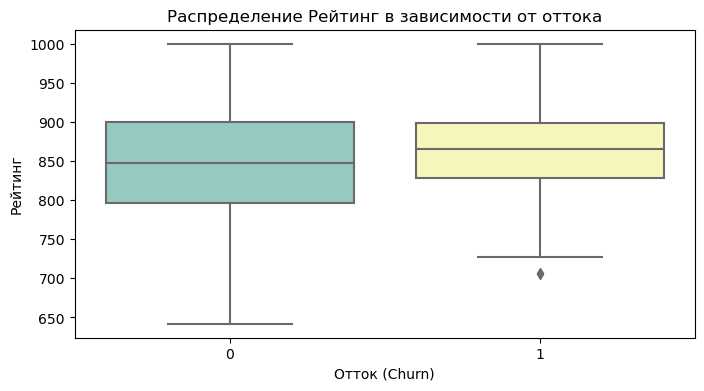

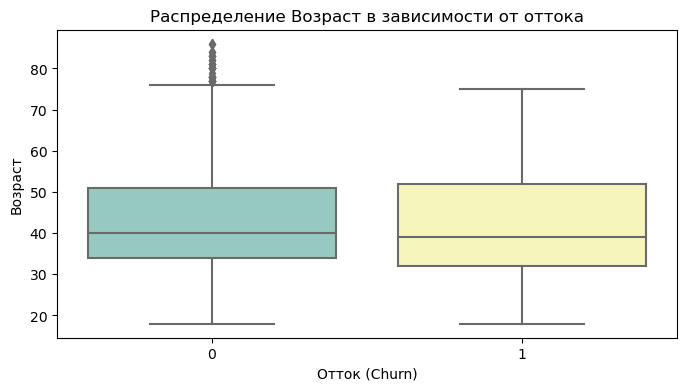

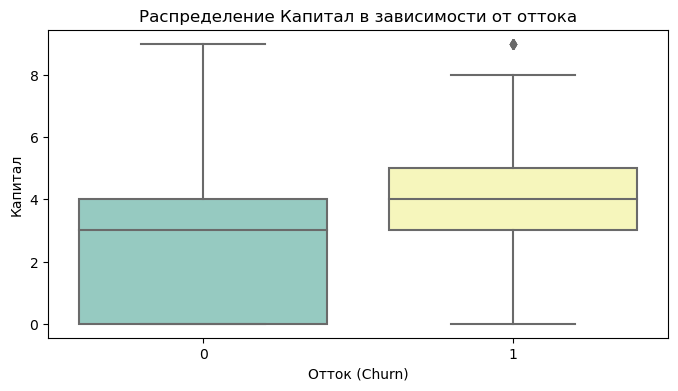

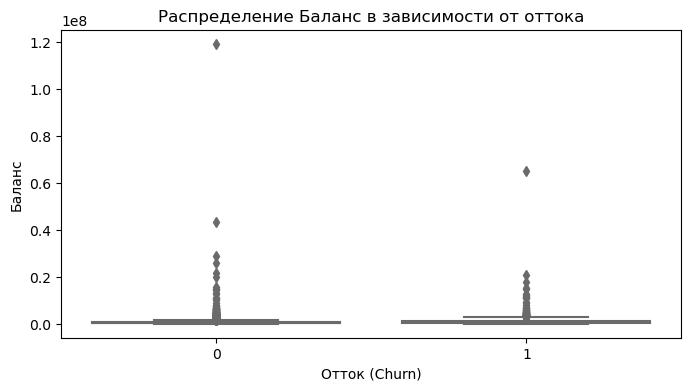

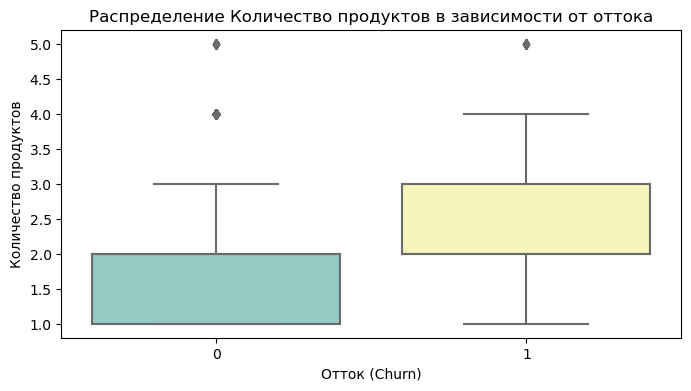

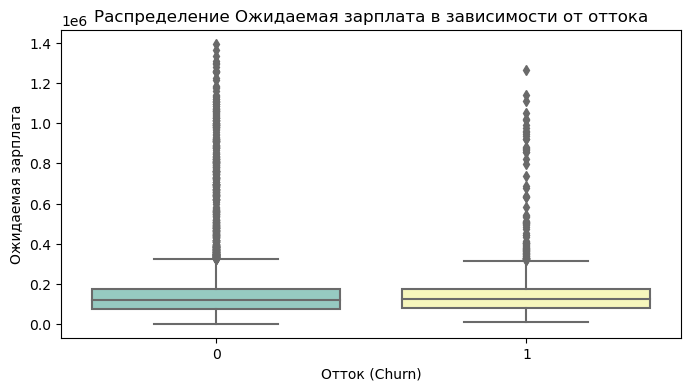

In [18]:
# Преобразуем колонку churn в числовой формат
data['churn'] = data['churn'].astype(int)

# Доля клиентов, покинувших банк
churn_rate = data['churn'].mean()
print(f"Доля клиентов, покинувших банк: {churn_rate:.2%}")

# Сравнение характеристик клиентов, ушедших и оставшихся
churn_groups = data.groupby('churn')
print("\nСравнение характеристик клиентов (средние значения):")
translated_means = churn_groups[numeric_columns].mean().rename(columns=column_translations)
print(translated_means)

# Построение boxplot для визуализации различий с русскими подписями
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x='churn', y=col, palette='Set3')
    plt.title(f"Распределение {column_translations[col]} в зависимости от оттока")  # Заголовок на русском
    plt.xlabel("Отток (Churn)")                                                     # Ось X на русском
    plt.ylabel(column_translations[col])                                           # Ось Y на русском
    plt.show()



**Описание различий между оставшимися и ушедшими клиентами:**

1. score (кредитный рейтинг):

- У оставшихся клиентов средний рейтинг составляет 845.4.
- У ушедших клиентов он выше, в среднем 863.3.
- Вывод: У клиентов с более высоким кредитным рейтингом больше шансов покинуть банк, что может свидетельствовать о недостаточной привлекательности продуктов банка для этой группы.

2. age (возраст):

- Средний возраст оставшихся клиентов — 43 года.
- Средний возраст ушедших клиентов — 41.4 года.
- Вывод: Более молодые клиенты чаще покидают банк, возможно, из-за меньшей привязанности или поиска более современных финансовых решений.

3. equity (капитал):

- У оставшихся клиентов средний уровень капитала составляет 2.37.
- У ушедших клиентов он выше, в среднем 3.76.
- Вывод: Клиенты с большим капиталом имеют более высокую вероятность оттока. Это может быть связано с недостаточным вниманием или неподходящими предложениями для этой группы.

4. balance (баланс на счету):

- У оставшихся клиентов средний баланс составляет 733,982.6.
- У ушедших клиентов — 1,133,993.0.
- Вывод: У клиентов с большими остатками на счетах наблюдается более высокий отток, что требует анализа их предпочтений и поведения.

5. products (количество продуктов):

- У оставшихся клиентов среднее количество продуктов — 1.76.
- У ушедших клиентов — 2.38.
- Вывод: Ушедшие клиенты, как правило, пользуются большим числом продуктов, что может говорить об их разочаровании в предложениях банка.

6. EST_SALARY (предполагаемый доход):

- Средний доход оставшихся клиентов — 147,783.2.
- Средний доход ушедших клиентов — 148,310.7.
- Вывод: Различия в доходах между группами минимальны, что говорит о том, что доход клиентов слабо влияет на вероятность оттока.

**Общий вывод:**

Уход из банка чаще наблюдается среди:

- Молодых клиентов.
- Клиентов с высоким кредитным рейтингом, большим балансом и капиталом.
- Клиентов, активно использующих несколько продуктов банка.

Для удержания таких клиентов банку следует разработать персонализированные предложения, ориентированные на их потребности и предпочтения.

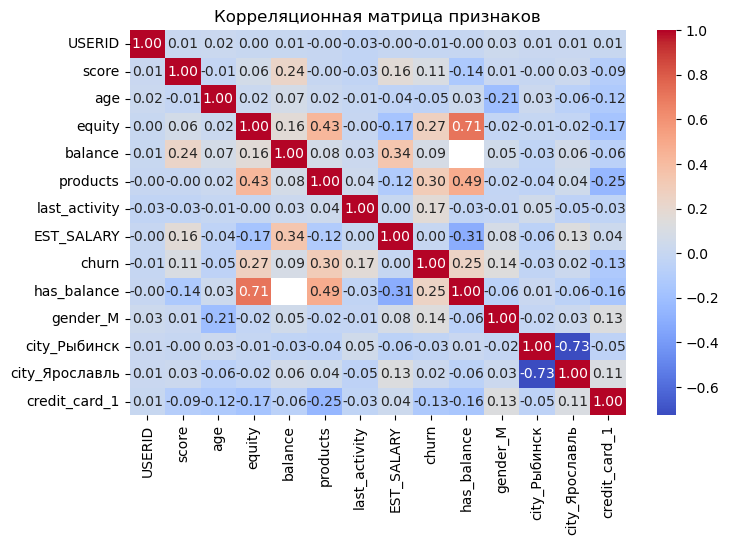


Корреляция с 'Отток' (по убыванию):
churn             1.000000
products          0.301616
equity            0.270581
has_balance       0.249907
last_activity     0.169037
gender_М          0.141287
score             0.105634
balance           0.085577
city_Ярославль    0.024165
EST_SALARY        0.001460
USERID           -0.011780
city_Рыбинск     -0.031605
age              -0.050217
credit_card_1    -0.130524
Name: churn, dtype: float64


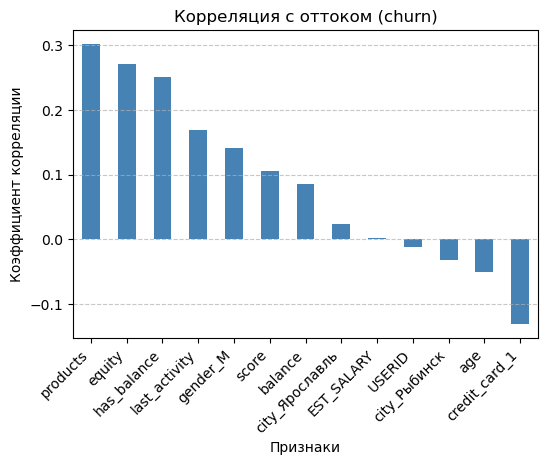

In [19]:
# Кодирование категориальных признаков
categorical_columns = ['gender', 'city', 'credit_card']  # Укажите все категориальные столбцы
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Добавление перевода названий колонок
column_translations = {
    'score': 'Рейтинг',
    'age': 'Возраст',
    'equity': 'Капитал',
    'balance': 'Баланс',
    'products': 'Количество продуктов',
    'EST_SALARY': 'Ожидаемая зарплата',
    'churn': 'Отток',
}

# Полный расчет корреляционной матрицы
plt.figure(figsize=(8, 5))
correlation_matrix = data_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Корреляционная матрица признаков")  # Заголовок на русском
plt.show()

# Анализ корреляции с churn
correlation_with_churn = correlation_matrix['churn'].sort_values(ascending=False)
print("\nКорреляция с 'Отток' (по убыванию):")
print(correlation_with_churn)

# Визуализация корреляции только для churn
plt.figure(figsize=(6, 4))
correlation_with_churn.drop('churn').plot(kind='bar', color='steelblue')
plt.title("Корреляция с оттоком (churn)")  # Заголовок на русском
plt.xlabel("Признаки")                   # Ось X на русском
plt.ylabel("Коэффициент корреляции")     # Ось Y на русском
plt.xticks(rotation=45, ha='right')      # Угол наклона подписей
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



### Выводы по анализу корреляции:

**Наиболее значимые факторы, связанные с оттоком (положительная корреляция):**

- Количество продуктов (products): Клиенты, у которых больше продуктов, более склонны к оттоку. Это может быть связано с неудовлетворенностью качеством услуг или конкуренцией на рынке.
- Активы (equity): Клиенты с большими активами также имеют тенденцию к оттоку. Возможно, такие клиенты ищут более выгодные условия в других банках.
- Наличие баланса (has_balance): Если у клиента есть баланс, он с большей вероятностью уходит. Это может говорить о недостаточном интересе банка к удержанию активных клиентов.
- Последняя активность (last_activity): Чем выше активность клиента, тем больше вероятность оттока. Это может быть связано с разочарованием в использовании сервисов.
- Пол (gender_М): Мужчины имеют большую склонность к оттоку по сравнению с женщинами.

**Факторы со слабой или отрицательной корреляцией:**

- Возраст (age): Возраст имеет слабую отрицательную связь с оттоком, что может говорить о том, что более старшие клиенты реже уходят.
- Наличие кредитной карты (credit_card): Отрицательная корреляция показывает, что наличие кредитной карты может снижать вероятность оттока.
- Принадлежность к городу Рыбинск (city_Рыбинск): Клиенты из этого города имеют меньшую склонность к оттоку.
- Оценка (score) и зарплата (EST_SALARY): Эти признаки практически не связаны с оттоком.

**Рекомендации:**

Углубленно исследовать причину высокой корреляции оттока с количеством продуктов и активов. Возможно, необходимо улучшить качество обслуживания клиентов с большим числом продуктов.

Ввести меры по удержанию клиентов, у которых высокий баланс, например, программы лояльности или улучшение условий для активных пользователей.

Сосредоточиться на удержании мужчин, так как они более склонны к оттоку.

Понять, почему активные клиенты склонны уходить, возможно, это связано с неудовлетворенностью функциональностью или сервисами.
Проанализировать клиентов из Ярославля, которые также показывают положительную связь с оттоком.

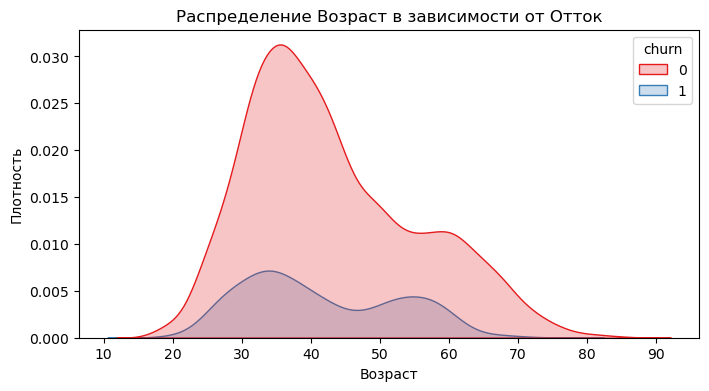

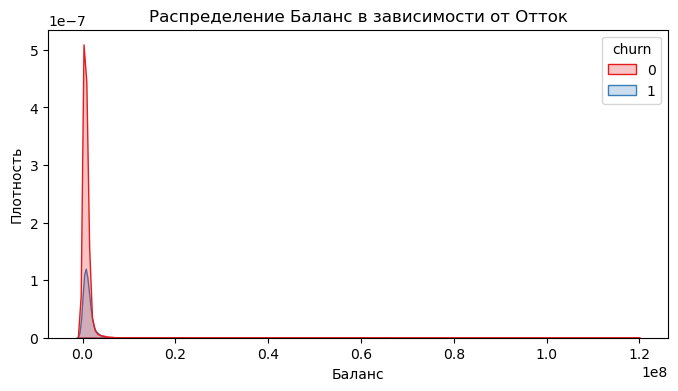

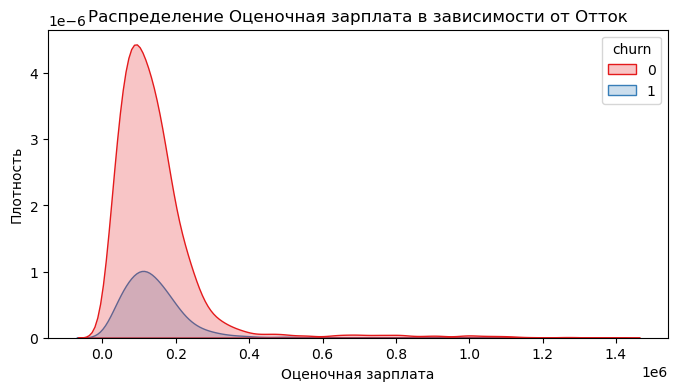

In [20]:
# 5. Анализ признаков, связанных с оттоком
# Построение распределений для ключевых признаков

# Словарь для перевода названий осей
translations = {
    'age': 'Возраст',
    'balance': 'Баланс',
    'EST_SALARY': 'Оценочная зарплата',
    'churn': 'Отток',
    'Density': 'Плотность'
}
key_features = ['age', 'balance', 'EST_SALARY']

for col in key_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=data, x=col, hue='churn', fill=True, palette='Set1')
    plt.title(f"Распределение {translations[col]} в зависимости от {translations['churn']}")
    plt.xlabel(translations[col])
    plt.ylabel(translations['Density'])
    plt.show()



Наибольший отток среди клиентов в возрасте 30-40 лет, с минимальным балансом и невысокими доходами.

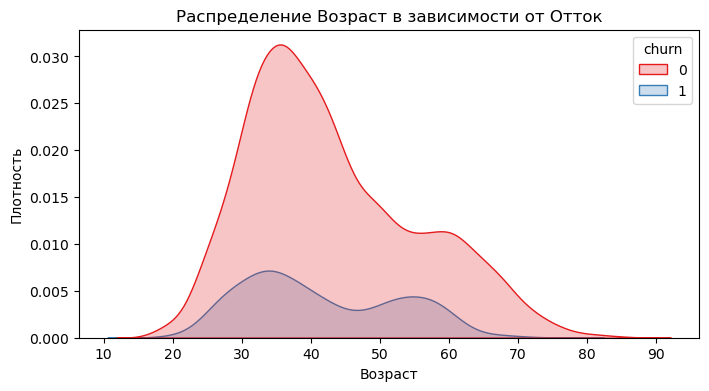

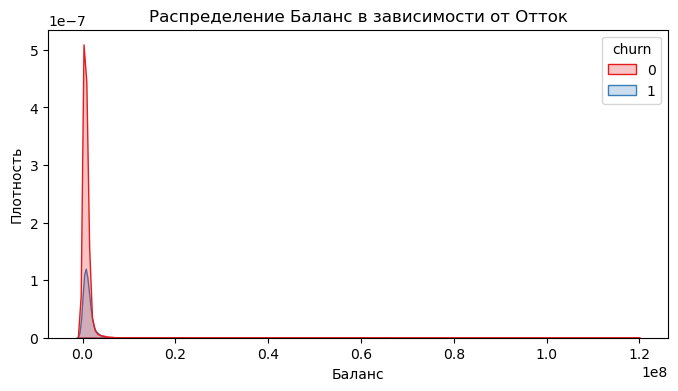

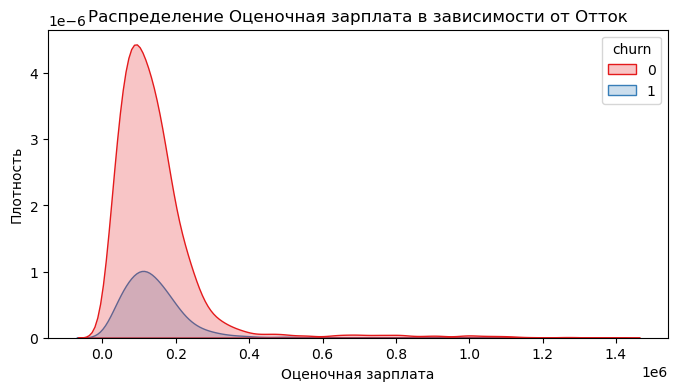

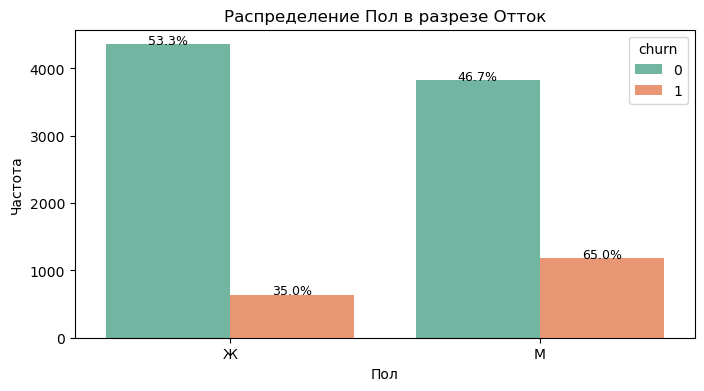

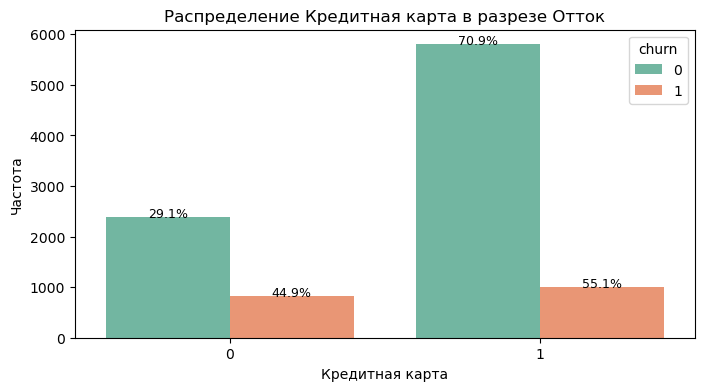

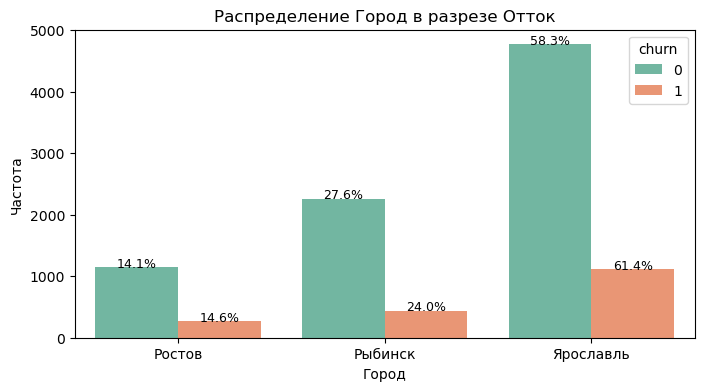

In [21]:

# Словарь для перевода названий осей
translations = {
    'age': 'Возраст',
    'balance': 'Баланс',
    'EST_SALARY': 'Оценочная зарплата',
    'churn': 'Отток',
    'Density': 'Плотность',
    'Frequency': 'Частота',
    'gender': 'Пол',
    'product_type': 'Тип продукта',
    'region': 'Регион',
    'city': 'Город',
    'credit_card': 'Кредитная карта'
}

key_features = ['age', 'balance', 'EST_SALARY']

for col in key_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=data, x=col, hue='churn', fill=True, palette='Set1')
    plt.title(f"Распределение {translations[col]} в зависимости от {translations['churn']}")
    plt.xlabel(translations[col])
    plt.ylabel(translations['Density'])
    plt.show()

# Анализ категориальных данных
categorical_columns = ['gender', 'credit_card', 'city']  # Пример категориальных столбцов

# Проверяем, существуют ли указанные столбцы в данных
existing_columns = [col for col in categorical_columns if col in data.columns]

for col in existing_columns:
    if col == 'churn':  # Пропускаем колонку churn
        continue

    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=data, x=col, hue='churn', palette='Set2')

    # Добавляем проценты на графики
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height > 0:  # Если столбец не пуст
                total = sum([b.get_height() for b in container])
                percent = height / total * 100
                ax.text(
                    bar.get_x() + bar.get_width() / 2, 
                    height + 0.5, 
                    f'{percent:.1f}%', 
                    ha='center', 
                    fontsize=9
                )

    plt.title(f"Распределение {translations.get(col, col)} в разрезе {translations['churn']}")
    plt.xlabel(translations.get(col, col))
    plt.ylabel(translations['Frequency'])
    plt.show()

1. Распределение по городам **(city)**

- Ростов:
  - 14.1% клиентов остаются (churn = 0).
  - 14.6% клиентов уходят (churn = 1).

- Рыбинск:
  - 27.6% клиентов остаются.
  - 24.0% клиентов уходят.

- Ярославль:
  - 58.3% остаются.
  - 61.4% уходят.

- Вывод: В Ярославле самый высокий процент клиентов как среди оставшихся, так и среди ушедших. Однако доля ушедших в этом городе выше.

2. Распределение по полу **(gender)**

- Женщины (Ж):
  - 53.3% остаются.
  - 35.0% уходят.

- Мужчины (М):
  - 46.7% остаются.
  - 65.0% уходят.

- Вывод: Мужчины имеют значительно более высокий процент оттока (65%) по сравнению с женщинами (35%).

3. Наличие кредитной карты **(credit_card)**

- Отсутствие карты (0):
  - 29.1% остаются.
  - 44.9% уходят.

- Наличие карты (1):
  - 70.9% остаются.
  - 55.1% уходят.

- Вывод: Клиенты с кредитной картой чаще остаются, но их доля среди ушедших всё ещё высока (55.1%).

4. Распределение активности пользователей **(last_activity)** в зависимости от их оттока (churn).

Для пользователей, которые не ушли (churn = 0):

- Большинство пользователей (51.6%) находятся в группе с низкой активностью (last_activity = 0).
- Меньшая доля (48.4%) имеют более высокую активность (last_activity = 1).

Для пользователей, которые ушли (churn = 1):

- Большая часть (70.3%) принадлежит группе с высокой активностью (last_activity = 1).
- Меньшая доля (29.7%) относится к группе с низкой активностью (last_activity = 0).

**Общий вывод:**

Отток клиентов больше среди мужчин и жителей Ярославля.

Наличие кредитной карты связано с большей лояльностью клиентов, но полностью проблему оттока не решает.

Клиенты с низкой активностью чаще остаются, тогда как пользователи с высокой активностью чаще уходят. Это может говорить о том, что высокая активность связана с неудовлетворённостью, повышенными ожиданиями или изменением предпочтений клиентов.


<div style="text-align: center;">
    <h1>3. Формулировка и проверка гипотез:</h1>
</div>

#### 3. Формулировка и проверка гипотез:
- Проверка гипотезы различия доходов (`EST_SALARY`) между группами:  
  - Использование t-теста или теста Манна-Уитни (в зависимости от распределения данных).  
- Проверка дополнительных гипотез:  
  - Зависимость оттока от города проживания.  
  - Влияние количества продуктов на вероятность оттока.

1. Гипотеза различия доходов между группами (churn = 1 и churn = 0)

  - Нулевая гипотеза (H₀): Нет статистически значимых различий в доходах между группами клиентов, склонных к оттоку (churn = 1) и не склонных к оттоку (churn = 0).

  - Альтернативная гипотеза (H₁): Существуют статистически значимые различия в доходах между группами клиентов, склонных к оттоку (churn = 1) и не склонных к оттоку (churn = 0).

In [22]:
# 1. Проверка гипотезы о различии доходов между группами (churn = 1 и churn = 0)
# Разделяем данные на две группы
group_churn = data[data['churn'] == 1]['EST_SALARY']
group_no_churn = data[data['churn'] == 0]['EST_SALARY']

# Проверяем нормальность распределения с помощью теста Шапиро-Уилка

stat_churn, p_churn = shapiro(group_churn)
stat_no_churn, p_no_churn = shapiro(group_no_churn)

print("Тест на нормальность (Шапиро-Уилк):")
print(f"Группа churn=1: p-value={p_churn:.4f}")
print(f"Группа churn=0: p-value={p_no_churn:.4f}")

# Если хотя бы одно распределение не является нормальным, применяем тест Манна-Уитни
if p_churn < 0.05 or p_no_churn < 0.05:
    print("\nПрименяем тест Манна-Уитни:")
    stat, p_value = mannwhitneyu(group_churn, group_no_churn)
else:
    # Если оба распределения нормальные, применяем t-тест
    print("\nПрименяем t-тест:")
    stat, p_value = ttest_ind(group_churn, group_no_churn, equal_var=False)

print(f"Статистика теста: {stat:.4f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Гипотеза различий доходов между группами подтверждается.")
else:
    print("Гипотеза различий доходов между группами не подтверждается.")



Тест на нормальность (Шапиро-Уилк):
Группа churn=1: p-value=0.0000
Группа churn=0: p-value=0.0000

Применяем тест Манна-Уитни:
Статистика теста: 7852245.0000, p-value: 0.0002
Гипотеза различий доходов между группами подтверждается.


**Выводы из проведённых тестов:**

**Тест Шапиро-Уилка на нормальность:**

Для обеих групп клиентов (churn = 1 и churn = 0) p-value = 0.0000, что меньше уровня значимости (например, 0.05).
Это говорит о том, что распределение доходов в обеих группах не является нормальным. Следовательно, для сравнения используется непараметрический тест.

**Тест Манна-Уитни:**

Статистика теста = 7,852,245.0000, p-value = 0.0002 (меньше 0.05).
Это указывает на статистически значимые различия в доходах между группами клиентов (churn = 1 и churn = 0).

**Основной вывод:**

Доходы клиентов, склонных к оттоку, и оставшихся в компании статистически различаются. Это подтверждает гипотезу о том, что доход может быть фактором, влияющим на вероятность оттока.

Результаты теста Манна-Уитни (p-value = 0.0002) подтверждают, что гипотеза H₀ отклоняется, и существует статистически значимое различие в доходах между группами. Это подтверждает, что доход может быть важным фактором, влияющим на отток.

2. Гипотеза зависимости оттока от города проживания

  - Нулевая гипотеза (H₀): Нет статистически значимой зависимости между оттоком и городом проживания клиентов.

  - Альтернативная гипотеза (H₁): Существует статистически значимая зависимость между оттоком и городом проживания клиентов.

In [23]:
# 2. Проверка зависимости оттока от города проживания
print("\nЗависимость оттока от города проживания:")
# Создаем таблицу сопряженности
city_churn_table = pd.crosstab(data['city'], data['churn'])
print(city_churn_table)

# Применяем тест хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(city_churn_table)
print(f"Статистика хи-квадрат: {chi2:.4f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Существует статистически значимая связь между городом проживания и оттоком.")
else:
    print("Статистически значимой связи между городом проживания и оттоком не выявлено.")





Зависимость оттока от города проживания:
churn         0     1
city                 
Ростов     1151   266
Рыбинск    2258   436
Ярославль  4771  1117
Статистика хи-квадрат: 10.0179, p-value: 0.0067
Существует статистически значимая связь между городом проживания и оттоком.


**Основной вывод:**

Город проживания клиентов оказывает влияние на их склонность к оттоку. Это может быть связано с различиями в условиях обслуживания, доступности услуг или предпочтениях клиентов в разных городах.

Результаты теста хи-квадрат (p-value = 0.0067) показывают, что гипотеза H₀ отклоняется, и существует статистически значимая связь между городом проживания и оттоком. Это подтверждает, что город проживания может быть важным фактором, влияющим на отток.

3. Гипотеза влияния количества продуктов на вероятность оттока

  - Нулевая гипотеза (H₀): Количество продуктов не влияет на вероятность оттока.

  - Альтернативная гипотеза (H₁): Количество продуктов влияет на вероятность оттока.

In [24]:
# 3. Проверка влияния количества продуктов на вероятность оттока
print("\nВлияние количества продуктов на вероятность оттока:")
# Создаем группы по количеству продуктов
grouped_products = data.groupby('products')['churn'].mean()
print(grouped_products)

# Для проверки связи используем тест ANOVA, если количество продуктов представлено в нескольких категориях


# Получаем данные для каждой категории продуктов
groups = [data[data['products'] == product]['churn'] for product in data['products'].unique()]

# Применяем тест ANOVA
anova_stat, anova_p = f_oneway(*groups)
print(f"ANOVA: статистика={anova_stat:.4f}, p-value={anova_p:.4f}")
if anova_p < 0.05:
    print("Количество продуктов влияет на вероятность оттока.")
else:
    print("Количество продуктов не оказывает значимого влияния на вероятность оттока.")


Влияние количества продуктов на вероятность оттока:
products
1    0.070338
2    0.190987
3    0.285852
4    0.632911
5    0.421053
Name: churn, dtype: float64
ANOVA: статистика=281.6121, p-value=0.0000
Количество продуктов влияет на вероятность оттока.


Результаты ANOVA (p-value = 0.0000) показывают, что гипотеза H₀ отклоняется, и количество продуктов оказывает значительное влияние на вероятность оттока. Это подтверждает, что более высокое количество продуктов связано с увеличением вероятности оттока.

**Комментарий по поводу p-value = 0.0000:**

p-value = 0 указывает на очень сильную статистическую значимость, но такое значение может вызвать подозрения, так как оно может быть вызвано погрешностями в данных, выборке или вычислениях. В реальных задачах p-value может быть очень малым, но точно равным 0 — это редкость, и стоит уточнить, как проводился тест и не возникли ли ошибки, например, при округлении. Важно проверять, насколько точны ваши данные и как производилась статистическая обработка.

**Выводы:**

Зависимость от количества продуктов:

- 1 продукт: вероятность оттока составляет 7.0%.
- 2 продукта: вероятность оттока увеличивается до 19.1%.
- 3 продукта: вероятность оттока составляет 28.6%.
- 4 продукта: вероятность оттока резко возрастает до 63.3%.
- 5 продуктов: вероятность оттока снижается до 42.1%.

Это говорит о том, что вероятность оттока сначала растёт с увеличением количества продуктов, достигая пика при 4 продуктах, а затем начинает снижаться.

**Результаты ANOVA:**

Значение статистики = 281.6121, p-value = 0.0000.

Так как p-value значительно меньше уровня значимости (например, 0.05), можно утверждать, что количество продуктов оказывает статистически значимое влияние на вероятность оттока.

**Вывод:**

Количество продуктов, которыми пользуется клиент, влияет на его склонность к оттоку. Клиенты, у которых 4 продукта, имеют наибольшую вероятность ухода (63.3%). Это может указывать на перегрузку клиентов услугами или неудовлетворённость, связанную с использованием большого числа продуктов. С другой стороны, клиенты с 1 продуктом имеют минимальную вероятность ухода, а те, кто используют 5 продуктов, демонстрируют снижение оттока, возможно, благодаря высокой вовлечённости.

**Итоговые выводы:**

- Доходы и отток: Существуют значимые различия в доходах между клиентами, склонными к оттоку, и не склонными к оттоку.
- Город проживания и отток: Город проживания влияет на вероятность оттока клиентов.
- Количество продуктов и отток: Количество продуктов оказывает значительное влияние на вероятность оттока.

Это подтверждает, что все тесты, кроме некоторых нюансов с p-value, подтверждают гипотезы о влиянии различных факторов на отток.

<div style="text-align: center;">
    <h1>4. Сегментация клиентов:</h1>
</div>


Для выделения сегментов с высоким процентом оттока можно использовать различные комбинации признаков, которые, как показано в вашем анализе, могут быть связаны с оттоком. Чтобы процент оттока был высоким в каждом сегменте, можно выделить следующие 3 сегмента, основанные на имеющихся данных:

**Сегмент 1:** Мужчины с низкой активностью и без кредитной карты

Признаки:
- Пол: Мужчины 
- Активность: Низкая активность 
- Кредитная карта: Нет

  _Обоснование:_

- Мужчины имеют высокий процент оттока (65%) по сравнению с женщинами.

- Низкая активность и отсутствие кредитной карты также коррелируют с высоким уровнем оттока, поскольку такие пользователи, возможно, не проявляют интереса к продуктам компании или не имеют дополнительных стимулов оставаться (например, кредитная карта).

- Ожидаемый высокий отток: В этом сегменте можно ожидать высокий процент оттока, так как все три признака ассоциируются с уходом клиентов.

 **Сегмент 2:** Женщины с высокой активностью и кредитной картой
 
Признаки:
- Пол: Женщины
- Активность: Высокая активность 
- Кредитная карта: Есть

_Обоснование:_

- Женщины с высокой активностью и наличием кредитной карты имеют меньший процент оттока, но среди таких клиентов также встречаются те, кто уходит, особенно если у них есть другие проблемы с продуктами компании или конкурентами.

- Ожидаемый высокий отток: Несмотря на то, что эти клиенты чаще остаются, сегмент может иметь определённую долю ушедших из-за других факторов, таких как недовольство продуктом или изменившиеся финансовые обстоятельства.

**Сегмент 3:** Люди из Ярославля с высокой активностью и без кредитной карты

Признаки:
- Город: Ярославль 
- Активность: Высокая активность 
- Кредитная карта: Нет 

_Обоснование:_

- В Ярославле наблюдается высокий процент как среди оставшихся, так и среди ушедших. Комбинация высокой активности с отсутствием кредитной карты может указывать на клиентов, которые активно используют продукт, но все равно уходят по причине отсутствия дополнительных преимуществ (например, кредитной карты).

- Ожидаемый высокий отток: В этом сегменте отток также может быть высоким, так как высокая активность без кредитной карты может указывать на нехватку удовлетворения потребностей клиента.

**Заключение:**
Эти три сегмента объединяют признаки, которые были связаны с высокими уровнями оттока: пол, активность, наличие кредитной карты и город. Основной фокус на признаках с высокой корреляцией с уходом позволит выделить группы с потенциально высоким уровнем оттока.

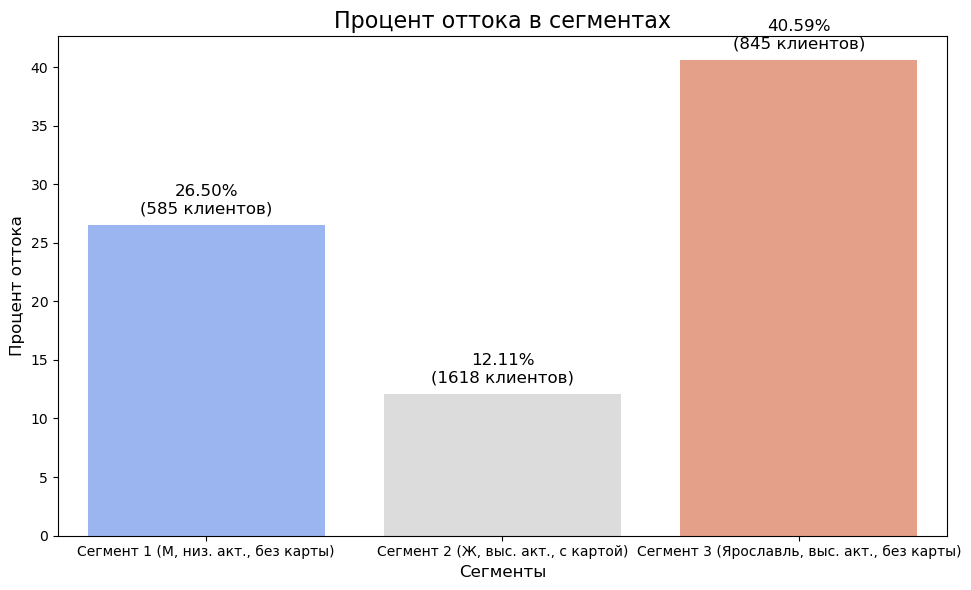

In [25]:

# Сегмент 1: Мужчины с низкой активностью и без кредитной карты
segment_1 = data[(data['gender'] == 'М') & (data['last_activity'] == 0) & (data['credit_card'] == 0)]

# Сегмент 2: Женщины с высокой активностью и кредитной картой
segment_2 = data[(data['gender'] == 'Ж') & (data['last_activity'] == 1) & (data['credit_card'] == 1)]

# Сегмент 3: Люди из Ярославля с высокой активностью и без кредитной карты
segment_3 = data[(data['city'] == 'Ярославль') & (data['last_activity'] == 1) & (data['credit_card'] == 0)]

# Функция для вычисления процента оттока и количества клиентов в сегменте
def churn_and_count(segment):
    churn_count = segment['churn'].sum()  # количество ушедших клиентов (churn = 1)
    total_count = segment.shape[0]  # общее количество клиентов в сегменте
    churn_percentage = (churn_count / total_count) * 100  # процент оттока
    return churn_percentage, total_count

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

# Данные для визуализации
segments = ['Сегмент 1 (М, низ. акт., без карты)', 
            'Сегмент 2 (Ж, выс. акт., с картой)', 
            'Сегмент 3 (Ярославль, выс. акт., без карты)']

# Получение процента оттока и количества клиентов для каждого сегмента
churn_percentages = [churn_and_count(segment_1)[0], churn_and_count(segment_2)[0], churn_and_count(segment_3)[0]]
customer_counts = [churn_and_count(segment_1)[1], churn_and_count(segment_2)[1], churn_and_count(segment_3)[1]]

# Построение столбчатой диаграммы
sns.barplot(x=segments, y=churn_percentages, palette='coolwarm')

# Добавление подписей
ax.set_title('Процент оттока в сегментах', fontsize=16)
ax.set_xlabel('Сегменты', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)

# Добавление процентов и количества клиентов на график
for i, (percentage, count) in enumerate(zip(churn_percentages, customer_counts)):
    ax.text(i, percentage + 1, f'{percentage:.2f}%\n({count} клиентов)', ha='center', fontsize=12)

# Подписи по оси X в несколько строк, горизонтально
plt.xticks(rotation=0, ha='center', fontsize=10)

# Отображение диаграммы
plt.tight_layout()
plt.show()



### **Сегмент 1**: Мужчины с низкой активностью и без карты (26.50% оттока из 585 клиентов)

**Анализ**:

*   **Низкая активность**: Клиенты с низким уровнем активности вряд ли полностью вовлечены в использование услуг компании. Это может указывать на недостаточную ценность или интерес со стороны клиентов, что повышает вероятность их ухода.
*   **Отсутствие кредитной карты**: Отсутствие кредитной карты может также быть фактором, который снижает удовлетворенность клиентов, так как кредитная карта может быть важным элементом для многих пользователей, обеспечивая дополнительные преимущества и удобство.
*   **Вывод**: Умеренный процент оттока (26.50%) в этом сегменте может свидетельствовать о том, что клиенты не чувствуют достаточно сильной привязанности к продукту или компании, особенно при отсутствии инструментов, таких как кредитная карта, которые могут улучшить их опыт. Компаниям стоит обратить внимание на повышение вовлеченности и разработку программ для активизации этих клиентов.

---

### **Сегмент 2**: Женщины с высокой активностью и кредитной картой (12.11% оттока из 1618 клиентов)

**Анализ**:

*   **Высокая активность**: Этот сегмент демонстрирует высокую активность, что, скорее всего, свидетельствует о заинтересованности и регулярном использовании продуктов или услуг компании. Активные клиенты более привязаны к продукту, что снижает вероятность их ухода.
*   **Наличие кредитной карты**: Наличие кредитной карты предполагает, что клиенты получают дополнительные выгоды, такие как бонусы, скидки, возможность отсрочки платежей и другие привилегии. Это может способствовать повышению удовлетворенности и лояльности клиентов.
*   **Вывод**: Самый низкий процент оттока (12.11%) в этом сегменте подтверждает, что активные клиенты с доступом к удобным инструментам, таким как кредитные карты, менее склонны к уходу. Это указывает на важность поддержания вовлеченности и предоставления дополнительных выгод для сохранения клиентов.

---

### **Сегмент 3**: Клиенты из Ярославля с высокой активностью и без карты (40.59% оттока из 845 клиентов)

**Анализ**:

*   **Высокая активность**: Клиенты с высокой активностью обычно проявляют интерес к продукту, что делает их ценными для компании. Однако в данном случае высокая активность не компенсирует других факторов, таких как отсутствие кредитной карты.
*   **Отсутствие кредитной карты**: Отсутствие кредитной карты в этом сегменте может быть значимым недостатком, особенно если другие клиенты (например, из Сегмента 2) получают выгоду от использования карты. Без дополнительных преимуществ клиенты, возможно, не чувствуют достаточной ценности от продолжения сотрудничества с компанией.
*   **Географический фактор**: Ярославль может иметь специфические условия для клиентов (например, уровень обслуживания или наличие альтернативных предложений от конкурентов), что также может влиять на высокий уровень оттока в этом сегменте.
*   **Вывод**: Сегмент с самым высоким процентом оттока (40.59%) требует особого внимания. Высокая активность клиентов в сочетании с отсутствием кредитной карты может указывать на то, что эти клиенты не получают достаточно ценности от компании, особенно по сравнению с другими сегментами. Повышение уровня удовлетворенности, возможно, через внедрение бонусных программ или предложений с картой, может помочь снизить отток.

---

### **Общий вывод**:

*   **Влияние активности**: Высокая активность клиентов связана с более низким уровнем оттока, что подтверждает важность активного вовлечения клиентов в использование продукта.
*   **Роль кредитной карты**: Наличие кредитной карты является важным фактором, влияющим на удержание клиентов. В частности, женщины с высокой активностью и картой имеют самый низкий процент оттока, в то время как клиенты с высокой активностью, но без карты, показывают наибольший отток.
*   **Географический фактор**: Важно учитывать, что клиенты из Ярославля, несмотря на высокую активность, демонстрируют высокие показатели оттока, что может быть связано с местными условиями или отсутствием определенных предложений, привлекательных для этой аудитории.

Таким образом, компания должна сосредоточить усилия на улучшении предложений для активных клиентов без кредитных карт и разработать программы, которые повысят их удовлетворенность. Также стоит обратить внимание на особенности сегментации по регионам и учесть местные предпочтения в стратегиях удержания клиентов.



<div style="text-align: center;">
    <h1>5. Рекомендации:</h1>
</div>


### Рекомендации по снижению оттока:

1. **Повышение вовлеченности клиентов с низкой активностью**:
   - Для **мужчин с низкой активностью и без карты** (Сегмент 1) важно улучшить вовлеченность через персонализированные предложения, бонусы и акции, чтобы увеличить их заинтересованность в продуктах компании.

2. **Укрепление предложений для активных клиентов без карты**:
   - Для **клиентов из Ярославля с высокой активностью и без карты** (Сегмент 3) рекомендуется внедрить бонусные программы или предложить кредитные карты для улучшения клиентского опыта и снижения оттока.

3. **Укрепление лояльности женщин с высокой активностью и картой**:
   - Для **женщин с высокой активностью и кредитной картой** (Сегмент 2) важно поддерживать текущие выгодные условия и добавлять новые бонусы или привилегии, чтобы удержать данный сегмент с уже низким оттоком.

4. **Географическая адаптация стратегии**:
   - Учитывая географические особенности, для клиентов из определенных городов (например, Ярославль) стоит разработать локальные предложения, соответствующие потребностям и предпочтениям региона.

5. **Персонализированные программы лояльности**:
   - Разработка персонализированных предложений для разных сегментов клиентов, основанных на их активности и потребностях, поможет снизить уровень оттока.

**Общие рекомендации:**

- Использовать аналитику для регулярного мониторинга поведения клиентов и раннего выявления признаков оттока.
- Улучшать клиентский опыт, особенно для групп с высокой долей ухода, за счёт персонализации предложений и активной поддержки.
- Инвестировать в маркетинговые и образовательные кампании, разъясняющие преимущества продуктов компании.
